# Macchi-Wang Time Series

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.ensemble import RandomForestRegressor

from itertools import product

from preprocessing.pipeline import preprocess_all
from preprocessing.visualization import plot_corr_matrix, plot_ccf_with_target

from models import (
    fit_rw_with_drift,
    forecast_rw_with_drift,
    expanding_window_forecast_rw_with_drift,
    fit_arima_model,
    forecast_arima_model,
    expanding_window_forecast_arima,
    select_var_lag,
    fit_var_model,
    forecast_var_model,
    fit_varx_model,
    forecast_varx_model,
    align_lagged_with_train_test,
    rf_time_series_cv,
)

## Preprocessing

### Data Cleaning

In [2]:
artifacts = preprocess_all(
    data_path="data/complete_dataset.csv",
    date_col="date",
    start="1996-01-01",
    end="2023-11-30",
    select_cols=[
        "date",
        "global_EUI_GDP_weighted", "GPR", "cpu_index",
        "Europe Brent Spot Price FOB (Dollars per Barrel)"
    ],
    rename_map={
        "global_EUI_GDP_weighted": "eui",
        "GPR": "gpr",
        "cpu_index": "cpu",
        "Europe Brent Spot Price FOB (Dollars per Barrel)": "oil_price",
    },
    log_cols=["eui", "gpr", "cpu", "oil_price"],   # keeps log_<col>
    diff_cols=["eui", "gpr", "cpu", "oil_price"],         # makes d_<col> and dlog_<col>
    add_event_flags=True,
    train_ratio=0.8,
    save=False,
    save_path=None,
    visualize_flags= None #{"variables": ("eui", "gpr", "cpu", "oil_price", "log_eui", "log_gpr", "log_cpu", "log_oil_price", "d_eui","d_gpr" ,"d_cpu", "d_oil_price", "dlog_eui","dlog_gpr", "dlog_cpu", "dlog_oil_price",), "lags": 36, "time_series": True, "acf": True, "pacf": True, "pacf_method": "ywm",},
)

features_df = artifacts["features_df"]
train_df = artifacts["train_df"]
test_df = artifacts["test_df"]


[Info] Missing values by column:
global_EUI_equally_weighted                         128
global_EUI_GDP_weighted                             128
GPR                                                 106
SHARE_GPR                                           106
N10                                                 106
GPRC_ARG                                            106
GPRC_AUS                                            106
GPRC_BEL                                            106
GPRC_BRA                                            106
GPRC_CAN                                            106
GPRC_CHE                                            106
GPRC_CHL                                            106
GPRC_CHN                                            106
GPRC_COL                                            106
GPRC_DEU                                            106
GPRC_DNK                                            106
GPRC_EGY                                            106
GPRC_ESP      

### Correlation

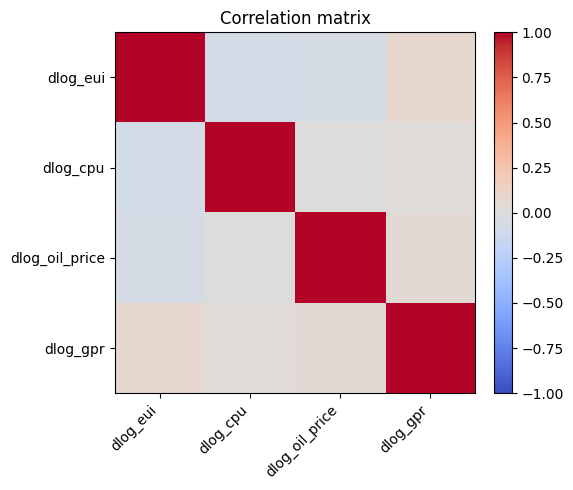

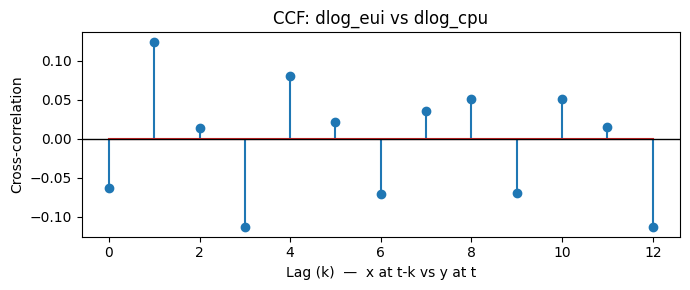

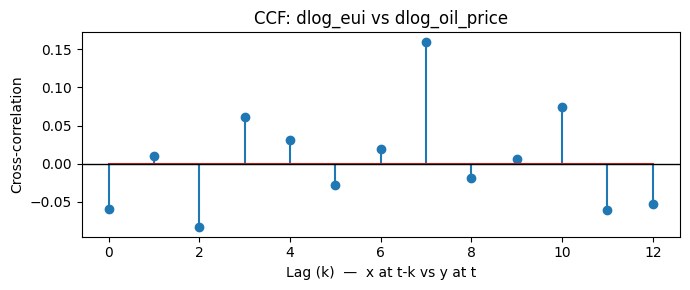

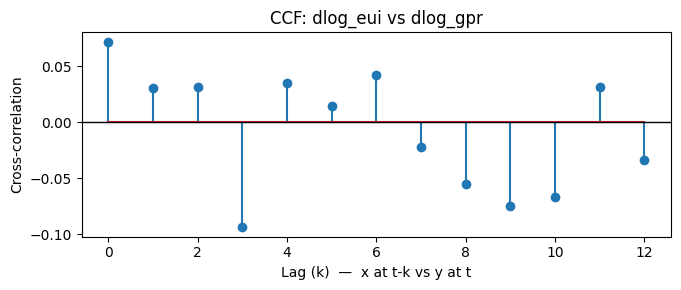

In [3]:
corr_vars = ["dlog_eui", "dlog_cpu", "dlog_oil_price", "dlog_gpr"]
plot_corr_matrix(features_df, variables=corr_vars, date_col="date")

plot_ccf_with_target(
    features_df,
    target="dlog_eui",
    predictors=["dlog_cpu", "dlog_oil_price", "dlog_gpr"],
    date_col="date",
    max_lag=12,
)


### TRAIN/TEST split

In [4]:
target_col_level = "eui"  # RW + RF target
target_col_arima = "dlog_eui"  # ARIMA target (ARIMA(d=1))

var_cols = ["dlog_eui", "log_gpr", "dlog_cpu", "dlog_oil_price"]

dlog_cols = [c for c in train_df.columns if c.startswith("dlog_")]
train_dlog = train_df[dlog_cols].copy()
test_dlog = test_df[dlog_cols].copy()

### ADF Test

In [5]:
def adf_report(series: pd.Series, name: str, maxlag=None):
    s = series.dropna()
    res = adfuller(s, autolag="AIC" if maxlag is None else None, maxlag=maxlag)
    stat, pval, usedlag, nobs, crit, icbest = res
    print(f"\nADF test for {name}")
    print("---------------------------------")
    print(f"Test statistic: {stat:.4f}")
    print(f"p-value:        {pval:.4f}")
    print(f"Lags used:      {usedlag}")
    print(f"Observations:   {nobs}")
    print("Critical values:")
    for k, v in crit.items():
        print(f"  {k}: {v:.4f}")
    print(f"IC best:        {icbest:.4f}")


original_vars = ["eui", "gpr", "cpu", "oil_price"]
dlog_vars = [f"dlog_{v}" for v in original_vars]

print("=== ADF on original level variables ===")
for v in original_vars:
    if v in train_df.columns:
        adf_report(train_df[v], v)
    else:
        print(f"\n[skip] {v} not in train_df.columns")

print("\n=== ADF on dlog_ variables ===")
for v in dlog_vars:
    if v in train_df.columns:
        adf_report(train_df[v], v)
    else:
        print(f"\n[skip] {v} not in train_df.columns")

=== ADF on original level variables ===

ADF test for eui
---------------------------------
Test statistic: -2.7765
p-value:        0.0617
Lags used:      8
Observations:   259
Critical values:
  1%: -3.4559
  5%: -2.8728
  10%: -2.5728
IC best:        70.3549

ADF test for gpr
---------------------------------
Test statistic: -5.2192
p-value:        0.0000
Lags used:      2
Observations:   265
Critical values:
  1%: -3.4553
  5%: -2.8725
  10%: -2.5726
IC best:        2495.5884

ADF test for cpu
---------------------------------
Test statistic: -2.9250
p-value:        0.0425
Lags used:      4
Observations:   263
Critical values:
  1%: -3.4555
  5%: -2.8726
  10%: -2.5727
IC best:        2392.0513

ADF test for oil_price
---------------------------------
Test statistic: -1.9751
p-value:        0.2976
Lags used:      1
Observations:   266
Critical values:
  1%: -3.4552
  5%: -2.8725
  10%: -2.5726
IC best:        1513.6239

=== ADF on dlog_ variables ===

ADF test for dlog_eui
---------

## Random Walk with Drift

In [6]:
# ---------------------------------------------------
# 1. Random Walk with Drift (on levels)
#    with 1-step ahead expanding-window forecasts
# ---------------------------------------------------
y_train_level = train_df[target_col_level]   # es. "eui"
y_test_level  = test_df[target_col_level]

# Fit once on the training sample (for in-sample residuals, etc.)
rw_fit = fit_rw_with_drift(y_train_level)

# Out-of-sample 1-step-ahead forecasts via expanding window
rw_fcast = expanding_window_forecast_rw_with_drift(
    y_train=y_train_level,
    y_test=y_test_level,
)

### Residuals

In [7]:
mu_rw = rw_fit["mu"]              # drift stimato
y_train = y_train_level           # es. train_df["eui"]

# fitted(t) = y_{t-1} + mu
rw_fitted_in = y_train.shift(1) + mu_rw

# residui in-sample (saltiamo il primo perché non ha lag)
rw_resid_in = (y_train - rw_fitted_in).dropna()
rw_resid_in.name = "rw_resid_in"

print("\nRW — in-sample residuals (head):")
print(rw_resid_in.head())


RW — in-sample residuals (head):
date
1996-02-01    0.012692
1996-03-01   -0.172322
1996-04-01    0.112600
1996-05-01    0.391035
1996-06-01   -0.627361
Name: rw_resid_in, dtype: float64


### Forecast

In [8]:
# Forecast errors (out-of-sample) per RW
rw_resid_oos = (y_test_level - rw_fcast).dropna()
rw_resid_oos.name = "rw_resid_oos"

print("\nRW — out-of-sample forecast errors:")
print(rw_resid_oos.head())


RW — out-of-sample forecast errors:
date
2018-05-01   -0.091649
2018-06-01    0.266758
2018-07-01    0.031779
2018-08-01   -0.040057
2018-09-01   -0.064652
Name: rw_resid_oos, dtype: float64


## ARIMA

### Best ARIMA

In [9]:
target_col_arima = target_col_level  # es. "eui"
y_train_arima = train_df[target_col_arima]
y_test_arima = test_df[target_col_arima]

# Griglia ricca di ordini ARIMA(p,1,q)
orders_to_try = [
    (p, 1, q)
    for p in range(0, 6)  # p = 0..5
    for q in range(0, 6)  # q = 0..5
]

seasonal_order = (0, 0, 0, 0)

arima_models = {}
arima_forecasts = {}
arima_errors = {}
arima_results = []  # per il riepilogo in DataFrame

for order in orders_to_try:
    print(f"\n=== Fitting ARIMA{order} on {target_col_arima} ===")
    try:
        res = fit_arima_model(
            y=y_train_arima,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
    except Exception as e:
        print(f"  FAILED for order {order}: {e}")
        continue

    arima_models[order] = res

    # Forecast sul test set
    fcast = forecast_arima_model(
        res=res,
        steps=len(y_test_arima),
        index=y_test_arima.index,
    )
    arima_forecasts[order] = fcast

    # Errori di previsione out-of-sample
    errors = (y_test_arima - fcast).dropna()
    arima_errors[order] = errors

    mse = float(np.mean(errors ** 2))
    rmse = float(np.sqrt(mse))

    # Residui in-sample
    resid_in = res.resid.dropna()

    # Ljung–Box sui residui in-sample (opzionale ma utile)
    lb = acorr_ljungbox(resid_in, lags=[12, 24], return_df=True)

    arima_results.append({
        "order": order,
        "aic": res.aic,
        "bic": res.bic,
        "rmse": rmse,
        "lb_pvalue_12": lb.loc[12, "lb_pvalue"],
        "lb_pvalue_24": lb.loc[24, "lb_pvalue"],
    })

# Riepilogo in tabella
arima_df = pd.DataFrame(arima_results).sort_values(by="rmse")
print("\n=== ARIMA model comparison (sorted by RMSE) ===")
print(arima_df)

# Scegli il best ARIMA (per esempio quello con RMSE minimo)
best_order = tuple(arima_df.iloc[0]["order"])
print(f"\nBest ARIMA order: {best_order}")

# Modello, residui e forecast errors del best ARIMA
arima_best_model = arima_models[best_order]


=== Fitting ARIMA(0, 1, 0) on eui ===

=== Fitting ARIMA(0, 1, 1) on eui ===

=== Fitting ARIMA(0, 1, 2) on eui ===

=== Fitting ARIMA(0, 1, 3) on eui ===

=== Fitting ARIMA(0, 1, 4) on eui ===

=== Fitting ARIMA(0, 1, 5) on eui ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b


=== Fitting ARIMA(1, 1, 0) on eui ===

=== Fitting ARIMA(1, 1, 1) on eui ===

=== Fitting ARIMA(1, 1, 2) on eui ===

=== Fitting ARIMA(1, 1, 3) on eui ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b


=== Fitting ARIMA(1, 1, 4) on eui ===

=== Fitting ARIMA(1, 1, 5) on eui ===

=== Fitting ARIMA(2, 1, 0) on eui ===


...

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred 


=== Fitting ARIMA(5, 1, 4) on eui ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred 


=== Fitting ARIMA(5, 1, 5) on eui ===

=== ARIMA model comparison (sorted by RMSE) ===
        order         aic         bic      rmse  lb_pvalue_12  lb_pvalue_24
22  (3, 1, 4)   68.007207   96.553963  0.353843  8.203069e-01  8.436676e-01
34  (5, 1, 4)   73.105715  108.789160  0.353915  9.221393e-01  8.819081e-01
28  (4, 1, 4)   69.741100  101.856201  0.354827  8.542094e-01  8.706304e-01
27  (4, 1, 3)   68.433478   97.010710  0.357762  8.559905e-01  8.756131e-01
23  (3, 1, 5)   70.512627  102.593311  0.359062  8.557171e-01  8.710985e-01
35  (5, 1, 5)   71.322581  110.532306  0.362708  9.460608e-01  9.252664e-01
33  (5, 1, 3)   72.014477  104.129578  0.363283  8.914703e-01  8.625749e-01
25  (4, 1, 1)   78.779670  100.212594  0.363419  2.015049e-01  1.664730e-01
10  (1, 1, 4)   76.789647   98.199714  0.364482  7.653223e-02  3.808339e-02
21  (3, 1, 3)   68.387084   93.392162  0.368681  7.780735e-01  8.172456e-01
29  (4, 1, 5)   70.407482  106.052686  0.383299  8.940095e-01  8.516020e-01


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### Residuals

In [10]:
arima_best_resid_in = arima_best_model.resid.dropna()

arima_best_resid_in.name = "arima_best_resid_in"

print("\nBest ARIMA — in-sample residuals (head):")
print(arima_best_resid_in.head())


Best ARIMA — in-sample residuals (head):
date
1996-01-01    0.358232
1996-02-01    0.039929
1996-03-01   -0.137505
1996-04-01   -0.054040
1996-05-01    0.368165
Name: arima_best_resid_in, dtype: float64


#### Forecast

In [11]:
# Expanding-window 1-step-ahead forecasts on the test set
arima_best_forecast = expanding_window_forecast_arima(
    y_train=y_train_arima,
    y_test=y_test_arima,
    order=best_order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

# Out-of-sample forecast errors (1-step-ahead, expanding window)
arima_best_errors_oos = (y_test_arima - arima_best_forecast).dropna()
arima_best_errors_oos.name = "arima_best_errors_oos"

print("\nBest ARIMA (expanding window) — out-of-sample forecast errors (head):")
print(arima_best_errors_oos.head())

C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b


Best ARIMA (expanding window) — out-of-sample forecast errors (head):
date
2018-05-01   -0.152585
2018-06-01    0.251601
2018-07-01    0.045146
2018-08-01   -0.039601
2018-09-01   -0.036461
Name: arima_best_errors_oos, dtype: float64


### ARIMA (2,1,0)

In [12]:
# ===================================================
# ARIMA(2,1,0): expanding-window forecast + residuals
# ===================================================

# Fixed order for this benchmark ARIMA
fixed_order = (2, 1, 0)
fixed_seasonal_order = (0, 0, 0, 0)

# 1-step-ahead expanding-window forecast on the ARIMA target (here: level EUI)
arima_210_forecast = expanding_window_forecast_arima(
    y_train=y_train_arima,
    y_test=y_test_arima,
    order=fixed_order,
    seasonal_order=fixed_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arima_210_forecast.name = "arima_210_forecast"


C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\time_series\ts_macchi_wang\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b

#### Residuals

In [13]:
# In-sample residuals re-using the ARIMA(2,1,0) model from the grid search
arima_210_model = arima_models[(2, 1, 0)]
arima_210_resid_in = arima_210_model.resid.dropna()
arima_210_resid_in.name = "arima_210_resid_in"

print("\nARIMA(2,1,0) — in-sample residuals (head):")
print(arima_210_resid_in.head())


ARIMA(2,1,0) — in-sample residuals (head):
date
1996-01-01    0.358232
1996-02-01    0.089215
1996-03-01   -0.127285
1996-04-01    0.047695
1996-05-01    0.402509
Name: arima_210_resid_in, dtype: float64


#### Forecasts

In [14]:
# Out-of-sample 1-step-ahead errors (test sample)
arima_210_errors_oos = (y_test_arima - arima_210_forecast).dropna()
arima_210_errors_oos.name = "arima_210_errors_oos"

print("\nARIMA(2,1,0) (expanding window) — out-of-sample errors (head):")
print(arima_210_errors_oos.head())


ARIMA(2,1,0) (expanding window) — out-of-sample errors (head):
date
2018-05-01   -0.105888
2018-06-01    0.261326
2018-07-01    0.126305
2018-08-01    0.037283
2018-09-01   -0.069387
Name: arima_210_errors_oos, dtype: float64


## Random Forest

In [15]:
# ---------------------------------------------------
# 1. Create RF lagged-feature dataset
# ---------------------------------------------------

rf_feature_cols = [
    "gpr", "cpu", "oil_price",
    "COVID_WINDOW_2020_03_11_2023_05_05",
    "RU_UA_WAR_PULSE_2022_02_24",
    "FUKUSHIMA_PULSE_2011_03_11",
    "GFC_WINDOW_2007_12_01_2009_06_30",
    "PARIS_COP21_PULSE_2015_12_12",
    "SEP11_PULSE_2001_09_11",
]

X_train_rf, y_train_rf, X_test_rf, y_test_rf = align_lagged_with_train_test(
    features_df=features_df,
    train_df=train_df,
    test_df=test_df,
    target_col=target_col_level,  # e.g. "eui"
    feature_cols=rf_feature_cols,
    max_lag=12,
    date_col="date",
)

print("Shapes:")
print("X_train_rf:", X_train_rf.shape)
print("y_train_rf:", y_train_rf.shape)
print("X_test_rf:", X_test_rf.shape)
print("y_test_rf:", y_test_rf.shape)

# ---------------------------------------------------
# 2. Define RF param_grid as dict of lists
# ---------------------------------------------------

#param_grid = {
    #"n_estimators": [200, 300, 500],
    #"max_depth": [3, 4, 5],
    #"min_samples_leaf": [1, 2, 4],}

# From the grid above the best params are:

# === RF Time-series CV results (sorted by MSFE) ===
#    n_estimators  max_depth  min_samples_leaf   cv_msfe
#24           500          5                 1  0.088497
#15           300          5                 1  0.089095
#6            200          5                 1  0.089632
#21           500          4                 1  0.089714
#25           500          5                 2  0.090639

# Best RF params: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 1}

#For computational efficiency, we simply use the best params found above.

param_grid = {
    "n_estimators": [500],
    "max_depth": [5],
    "min_samples_leaf": [1],
}

# ---------------------------------------------------
# 3. Time-series CV scoring for one param combination
# ---------------------------------------------------

def ts_cv_score_rf(
        X, y,
        params,
        initial_train_size,
        h=1,
        step=1,
        random_state=6,
):
    """
    Expanding-window CV for RF.
    Returns mean MSFE (mean squared forecast error).
    """
    n = len(y)
    msfes = []

    train_start = 0
    train_end = initial_train_size

    while True:
        test_start = train_end
        test_end = test_start + h

        if test_end > n:
            break

        X_train_cv = X.iloc[train_start:train_end]
        y_train_cv = y.iloc[train_start:train_end]
        X_test_cv = X.iloc[test_start:test_end]
        y_test_cv = y.iloc[test_start:test_end]

        rf = RandomForestRegressor(
            random_state=random_state,
            n_jobs=-1,
            **params,
        )
        rf.fit(X_train_cv, y_train_cv)
        y_pred_cv = rf.predict(X_test_cv)

        msfe = np.mean((y_test_cv.values - y_pred_cv) ** 2)
        msfes.append(msfe)

        train_end += step  # expand window

    return np.mean(msfes) if msfes else np.inf


# ---------------------------------------------------
# 4. Loop over all combinations of the param_grid
# ---------------------------------------------------

keys = list(param_grid.keys())
values_product = list(product(*param_grid.values()))

cv_results = []
initial_train_size = int(len(y_train_rf) * 0.5)

print("\nStarting RF Grid Search...\n")

for vals in values_product:
    params = dict(zip(keys, vals))
    print("Testing:", params)

    msfe_cv = ts_cv_score_rf(
        X=X_train_rf,
        y=y_train_rf,
        params=params,
        initial_train_size=initial_train_size,
        h=1,
        step=1,
        random_state=6,
    )

    cv_results.append({**params, "cv_msfe": msfe_cv})

cv_results_df = pd.DataFrame(cv_results).sort_values(by="cv_msfe")
print("\n=== RF Time-series CV results (sorted by MSFE) ===")
print(cv_results_df.head())

# ---------------------------------------------------
# 5. Select best parameters
# ---------------------------------------------------

best = cv_results_df.iloc[0]
best_params = {
    "n_estimators": int(best["n_estimators"]),
    "max_depth": int(best["max_depth"]),
    "min_samples_leaf": int(best["min_samples_leaf"]),
}

print("\nBest RF params:", best_params)

# ---------------------------------------------------
# 6. Fit final RF on full training set & forecast test
# ---------------------------------------------------

rf_best = RandomForestRegressor(
    n_jobs=-1,
    random_state=6,
    **best_params,
)

rf_best.fit(X_train_rf, y_train_rf)

rf_fcast = rf_best.predict(X_test_rf)
rf_fcast_series = pd.Series(rf_fcast, index=X_test_rf.index, name="rf_forecast")

print("\nRandom Forest final forecast (head):")
print(rf_fcast_series.head())


Shapes:
X_train_rf: (256, 120)
y_train_rf: (256,)
X_test_rf: (67, 120)
y_test_rf: (67,)

Starting RF Grid Search...

Testing: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 1}

=== RF Time-series CV results (sorted by MSFE) ===
   n_estimators  max_depth  min_samples_leaf   cv_msfe
0           500          5                 1  0.088497

Best RF params: {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 1}

Random Forest final forecast (head):
date
2018-05-01    0.899221
2018-06-01    0.887813
2018-07-01    0.985061
2018-08-01    1.126785
2018-09-01    1.119872
Name: rf_forecast, dtype: float64


### Residuals

In [16]:
# Fitted values sul training per RF
rf_fitted_in = rf_best.predict(X_train_rf)
rf_fitted_in = pd.Series(rf_fitted_in, index=X_train_rf.index, name="rf_fitted_in")

# Residui in-sample RF
rf_resid_in = (y_train_rf - rf_fitted_in).dropna()
rf_resid_in.name = "rf_resid_in"

print("\nRF — in-sample residuals:")
print(rf_resid_in.head())


RF — in-sample residuals:
date
1997-01-01    0.021624
1997-02-01    0.006667
1997-03-01    0.007100
1997-04-01   -0.105174
1997-05-01    0.010600
Name: rf_resid_in, dtype: float64


### Forecast

In [17]:
# Forecast errors (out-of-sample) RF
rf_resid_oos = (y_test_rf - rf_fcast_series).dropna()
rf_resid_oos.name = "rf_resid_oos"

print("\nRF — out-of-sample forecast errors:")
print(rf_resid_oos.head())


RF — out-of-sample forecast errors:
date
2018-05-01   -0.030263
2018-06-01    0.249809
2018-07-01    0.187238
2018-08-01    0.008471
2018-09-01   -0.046400
Name: rf_resid_oos, dtype: float64


## Final Results

### Confront the residuals


Random Walk with Drift (in-sample, level)
------------------------------
Mean:   0.000000
Std:    0.304470
Min:    -1.020485
Max:    0.989767


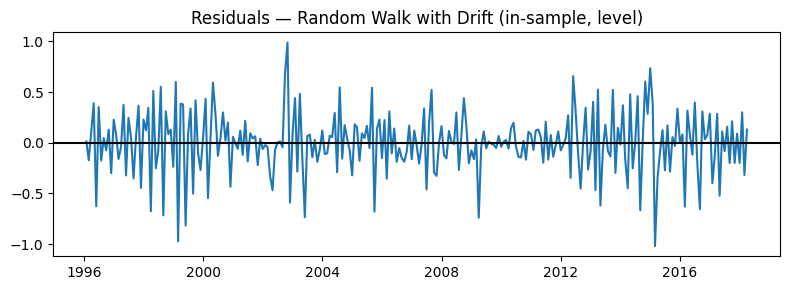

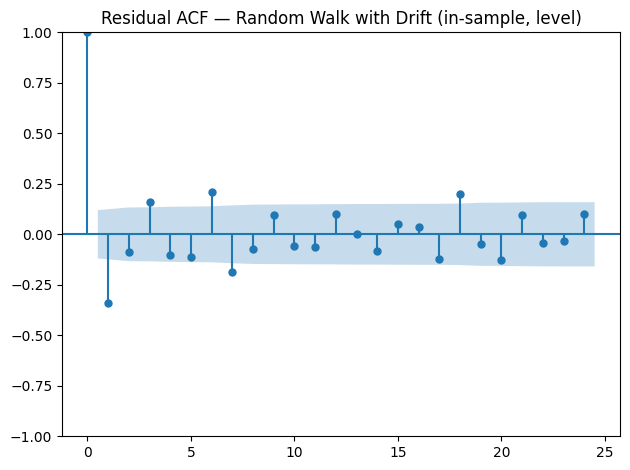


Best ARIMA(3, 1, 4) (in-sample, level)
------------------------------
Mean:   0.013564
Std:    0.267047
Min:    -0.734916
Max:    1.117735


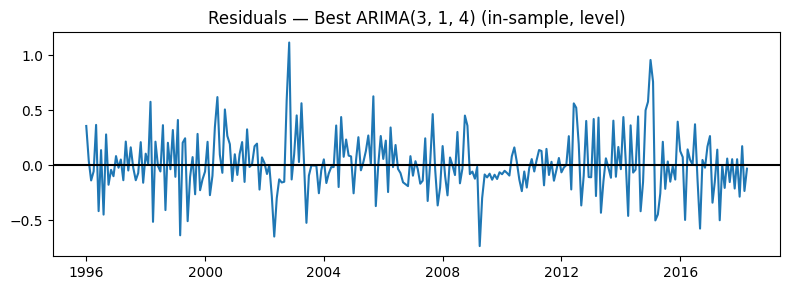

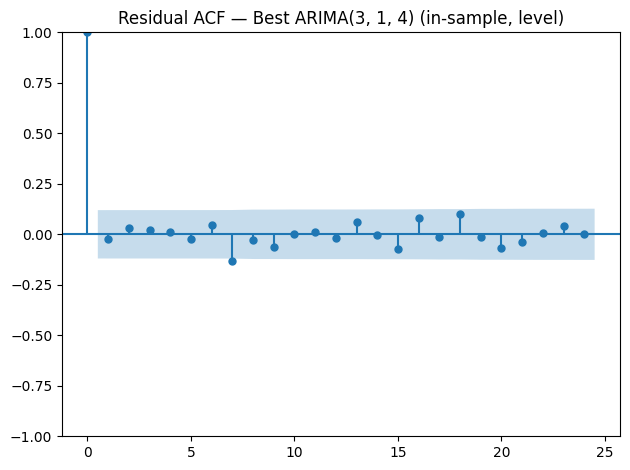


ARIMA(2,1,0) (in-sample, level)
------------------------------
Mean:   0.005374
Std:    0.279394
Min:    -0.774076
Max:    1.265929


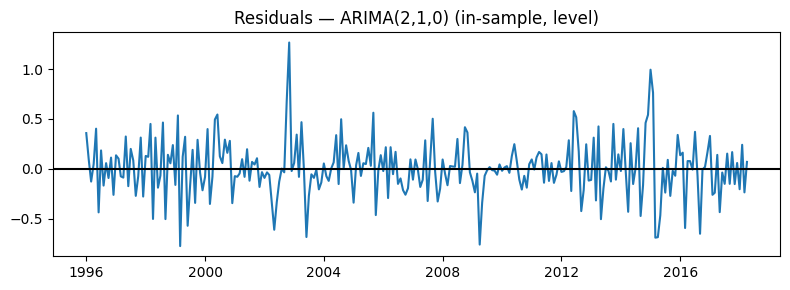

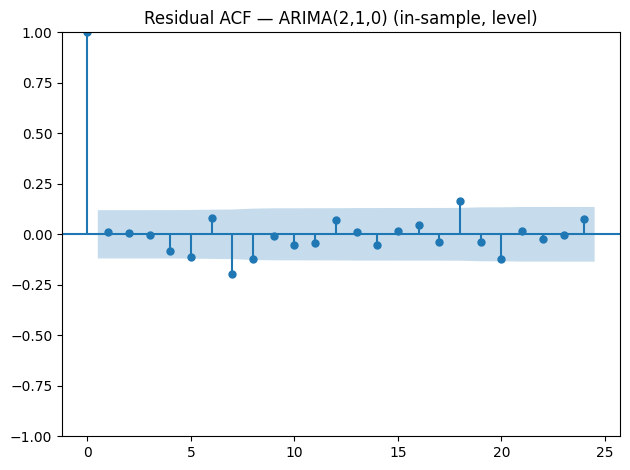


Random Forest (in-sample, level)
------------------------------
Mean:   -0.000199
Std:    0.151760
Min:    -0.425006
Max:    0.490277


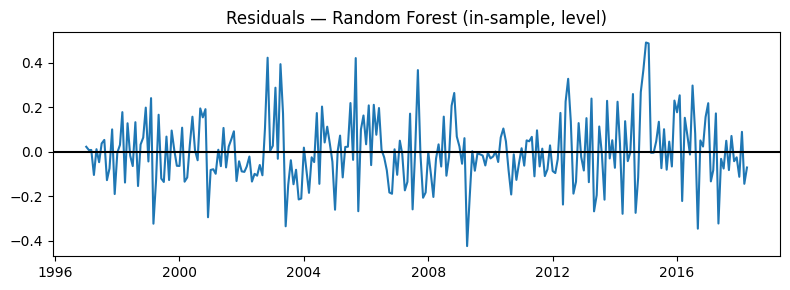

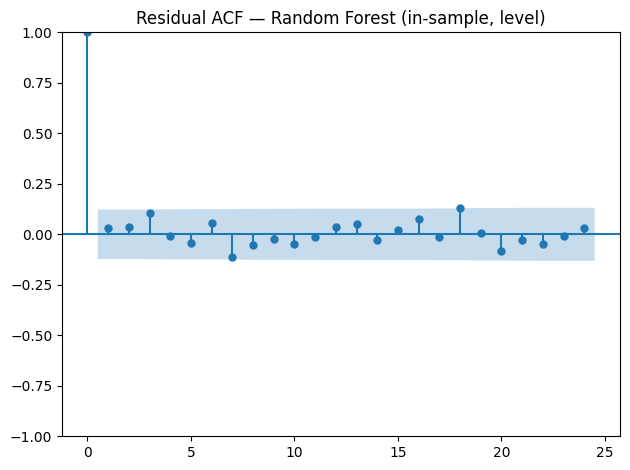

In [18]:
def quick_resid_diagnostics(resid: pd.Series, title: str):
    print(f"\n{title}")
    print("------------------------------")
    print(f"Mean:   {resid.mean():.6f}")
    print(f"Std:    {resid.std():.6f}")
    print(f"Min:    {resid.min():.6f}")
    print(f"Max:    {resid.max():.6f}")

    plt.figure(figsize=(8,3))
    plt.plot(resid)
    plt.axhline(0, color="black")
    plt.title(f"Residuals — {title}")
    plt.tight_layout()
    plt.show()

    plot_acf(resid.dropna(), lags=24)
    plt.title(f"Residual ACF — {title}")
    plt.tight_layout()
    plt.show()

# Esempi:
quick_resid_diagnostics(rw_resid_in,          "Random Walk with Drift (in-sample, level)")
quick_resid_diagnostics(arima_best_resid_in,  f"Best ARIMA{best_order} (in-sample, level)")
quick_resid_diagnostics(arima_210_resid_in, "ARIMA(2,1,0) (in-sample, level)")
quick_resid_diagnostics(rf_resid_in,          "Random Forest (in-sample, level)")

### Confront the forecasts

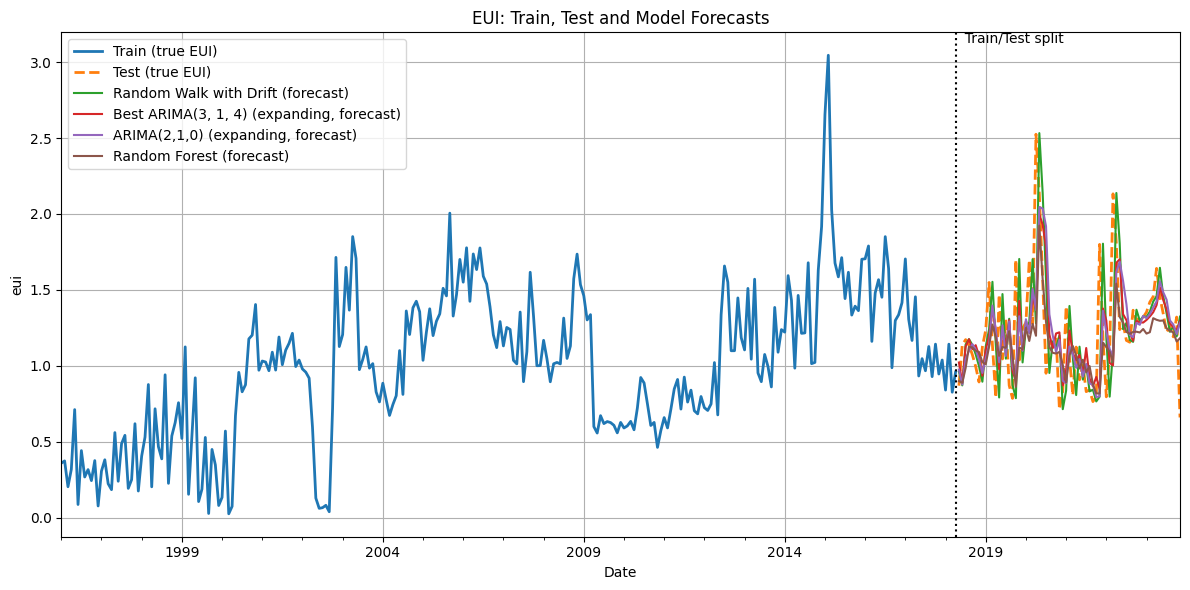

In [19]:
# -----------------------------
# 1. True series (levels)
# -----------------------------
# (these should already be defined earlier)
# y_train_level = train_df[target_col_level]
# y_test_level  = test_df[target_col_level]

# -----------------------------
# 2. Build a combined DataFrame
# -----------------------------
plot_df = pd.DataFrame({
    "train_true": y_train_level,
    "test_true": y_test_level,
    "rw": rw_fcast,                    # RW with drift (expanding)
    "arima_best": arima_best_forecast, # best ARIMA from grid
    "arima_210": arima_210_forecast,   # fixed ARIMA(2,1,0), expanding
    "rf": rf_fcast_series,             # Random Forest
})

# -----------------------------
# 3. Plot: train, test, forecasts
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# Train part
plot_df["train_true"].plot(
    ax=ax,
    label="Train (true EUI)",
    linewidth=2,
)

# Test true values
plot_df["test_true"].plot(
    ax=ax,
    label="Test (true EUI)",
    linewidth=2,
    linestyle="--",
)

# Model forecasts on test period
plot_df["rw"].plot(
    ax=ax,
    label="Random Walk with Drift (forecast)",
)
plot_df["arima_best"].plot(
    ax=ax,
    label=f"Best ARIMA{best_order} (expanding, forecast)",
)
plot_df["arima_210"].plot(
    ax=ax,
    label="ARIMA(2,1,0) (expanding, forecast)",
)
plot_df["rf"].plot(
    ax=ax,
    label="Random Forest (forecast)",
)

# Vertical line at train/test split
split_date = train_df.index[-1]
ax.axvline(split_date, color="black", linestyle=":", linewidth=1.5)
ax.text(
    split_date,
    ax.get_ylim()[1],
    "  Train/Test split",
    va="top",
    ha="left",
)

ax.set_title("EUI: Train, Test and Model Forecasts")
ax.set_xlabel("Date")
ax.set_ylabel(target_col_level)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

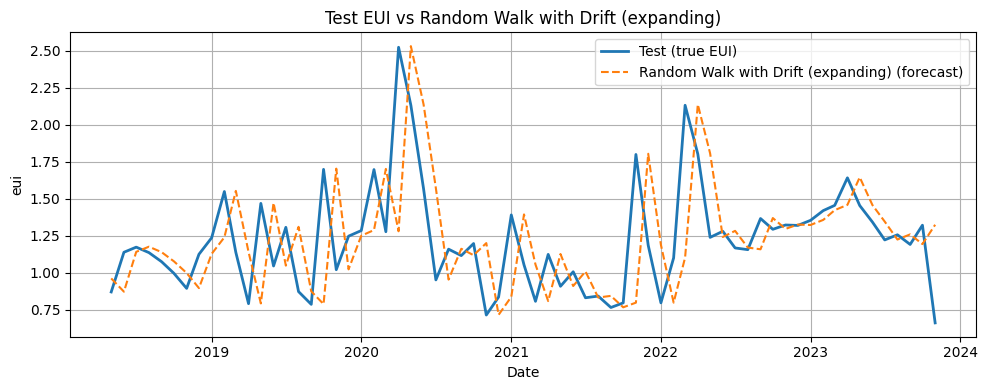

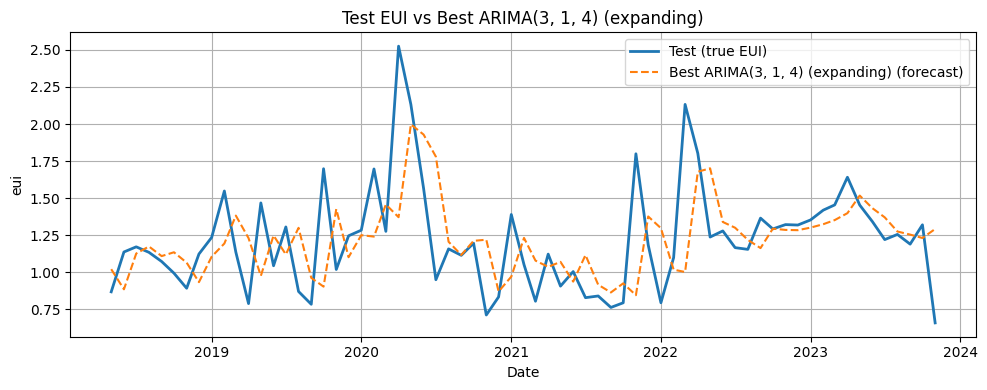

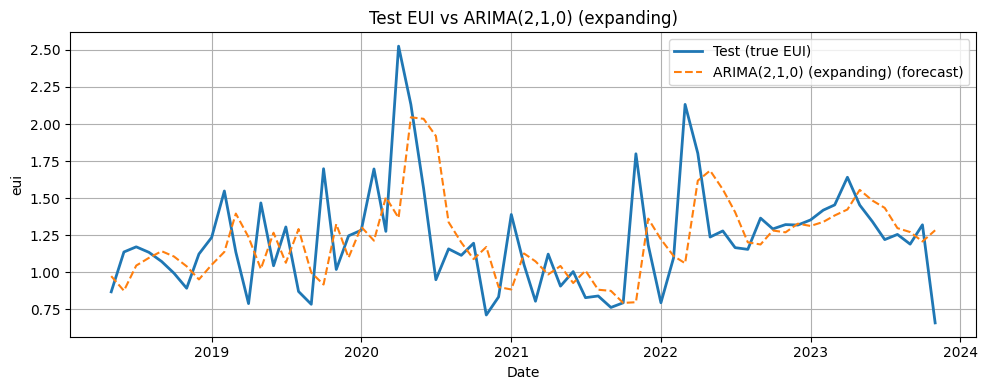

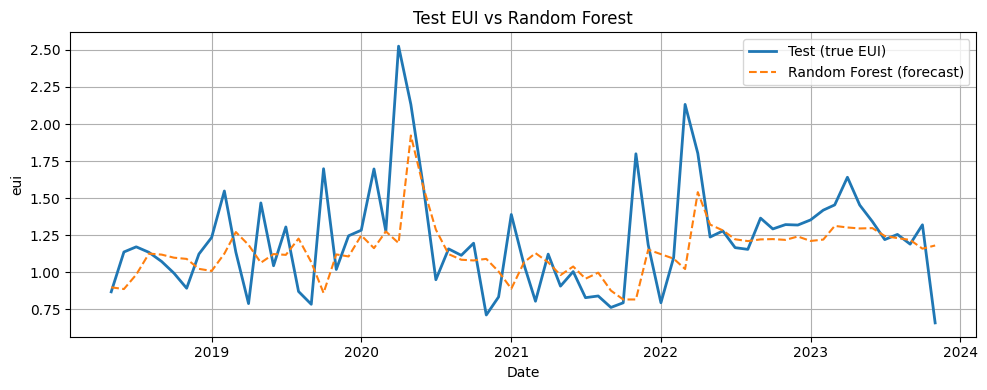

In [20]:
# ---------------------------------------------------
# Plots: true test EUI vs each model forecast (separately)
# ---------------------------------------------------

y_true_test = y_test_level

forecast_dict = {
    "Random Walk with Drift (expanding)": rw_fcast.reindex(y_true_test.index),
    f"Best ARIMA{best_order} (expanding)": arima_best_forecast.reindex(y_true_test.index),
    "ARIMA(2,1,0) (expanding)": arima_210_forecast.reindex(y_true_test.index),
    "Random Forest": rf_fcast_series.reindex(y_true_test.index),
}

for model_name, y_hat in forecast_dict.items():
    # Drop any rows where either true or forecast is missing
    tmp = pd.concat([y_true_test, y_hat], axis=1, keys=["y_true", "y_hat"]).dropna()

    fig, ax = plt.subplots(figsize=(10, 4))

    # True values (test)
    ax.plot(
        tmp.index,
        tmp["y_true"],
        label="Test (true EUI)",
        linewidth=2,
    )

    # Model forecast
    ax.plot(
        tmp.index,
        tmp["y_hat"],
        label=f"{model_name} (forecast)",
        linestyle="--",
    )

    ax.set_title(f"Test EUI vs {model_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel(target_col_level)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


### Evaluate the forecasts

In [21]:
def compute_metrics(y_true, y_pred):
    """
    Returns a dictionary with MSFE, RMSFE, MAFE, MAPE.
    """
    err = y_true - y_pred
    abs_err = np.abs(err)

    metrics = {
        "MSFE": np.mean(err ** 2),
        "RMSFE": np.sqrt(np.mean(err ** 2)),
        "MAFE": np.mean(abs_err),
        "MAPE": np.mean(abs_err / np.abs(y_true)) * 100,
    }
    return metrics

# Align predictions with the true test values (levels)
y_true = y_test_level

metrics_rw        = compute_metrics(y_true, rw_fcast)
metrics_arimaBest = compute_metrics(y_true, arima_best_forecast)
metrics_arima210  = compute_metrics(y_true, arima_210_forecast)
metrics_rf        = compute_metrics(y_true, rf_fcast_series)

metrics_df = pd.DataFrame({
    "Random Walk":               metrics_rw,
    f"ARIMA{best_order} (best)": metrics_arimaBest,
    "ARIMA(2,1,0) (expanding)":  metrics_arima210,
    "Random Forest":             metrics_rf,
}).T  # models as rows

print("\n=== Forecast Accuracy Comparison ===")
print(metrics_df.round(4))


=== Forecast Accuracy Comparison ===
                            MSFE   RMSFE    MAFE     MAPE
Random Walk               0.1544  0.3929  0.2820  23.1729
ARIMA(3, 1, 4) (best)     0.1246  0.3529  0.2412  20.4167
ARIMA(2,1,0) (expanding)  0.1297  0.3602  0.2512  20.9492
Random Forest             0.1115  0.3340  0.2118  16.9893
